All of this is a tutorial I followed, and is not original code.
I find writing out code and running it to help me understand it better than just reading it.

In [1]:
# 1 imports

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim

In [2]:
# 2 RandomWiring class
# essentially this defines how neurons connect to eachother
# inside the LNN. It starts by creating random adjacency between 
# neurons

class RandomWiring:
    def __init__(self, input_dim, output_dim, neuron_count):
        self.input_dim = input_dim #number of input features
        self.output_dim = output_dim #number of output features
        self.neuron_count = neuron_count #number of neurons in layer
        self.adjacency_matrix = np.random.uniform(0, 1, (neuron_count, neuron_count)) #adjacency matrix for connections btwn neurons
        self.sensory_adjacency_matrix = np.random.uniform(0, 1, (input_dim, neuron_count)) #adjacency matrix for sensory inputs to neurons

    def rev_initializer(self):
        return np.random.uniform(-0.2, 0.2, (self.neuron_count, self.neuron_count)) #initializes reversal potentials for neuron connections
    
    def sensory_rev_initializer(self):
        return np.random.uniform(-0.2, 0.2, (self.input_dim, self.neuron_count)) #initializes reversal potentials for sensory inputs

In [13]:
# 3 LIFNeuronLayer Class
# models the behavior of Leaky Integrate-and-Fire neurons
# Initializes neuron params and defines forward pass for computing neuron states
# LIF dynamics are described using ODE and during the forward pass we solve the states
# using Euler Explicit method

class LIFNeuronLayer(nn.Module):
    def __init__(self, wiring, ode_unfolds=12, epsilon=1e-8):
        super(LIFNeuronLayer, self).__init__()
        self.wiring = wiring # Wiring object containing connection info
        self.ode_unfolds = ode_unfolds #number of ODE solver iterations
        self.epsilon = epsilon #small value to avoid division by zero
        self.softplus = nn.Softplus() #softplus activation function

        #initialization ranges for params
        GLEAK_MIN, GLEAK_MAX = 0.001, 1.0
        VLEAK_MIN, VLEAK_MAX = -0.2, 0.2
        CM_MIN, CM_MAX = 0.4, 0.6
        W_MIN, W_MAX = 0.001, 1.0
        SIGMA_MIN, SIGMA_MAX = 3, 8
        MU_MIN, MU_MAX = 0.3, 0.8
        SENSORY_W_MIN, SENSORY_W_MAX = 0.001, 1.0
        SENSORY_SIGMA_MIN, SENSORY_SIGMA_MAX = 3, 8
        SENSORY_MU_MIN, SENSORY_MU_MAX = 0.3, 0.8

        #initialize neuron params with random vals within range
        self.gleak = nn.Parameter(torch.rand(wiring.neuron_count) * (GLEAK_MAX - GLEAK_MIN) + GLEAK_MIN)
        self.vleak = nn.Parameter(torch.rand(wiring.neuron_count) * (VLEAK_MAX - VLEAK_MIN) + VLEAK_MIN)
        self.cm = nn.Parameter(torch.rand(wiring.neuron_count) * (CM_MAX - CM_MIN) + CM_MIN)
        self.w = nn.Parameter(torch.rand(wiring.neuron_count, wiring.neuron_count) * (W_MAX - W_MIN) + W_MIN)
        self.sigma = nn.Parameter(torch.rand(wiring.neuron_count, wiring.neuron_count) * (SIGMA_MAX - SIGMA_MIN) + SIGMA_MIN)
        self.mu = nn.Parameter(torch.rand(wiring.neuron_count, wiring.neuron_count) * (MU_MAX - MU_MIN) + MU_MIN)
        self.rev = nn.Parameter(torch.Tensor(wiring.rev_initializer()))

        #initailize sensory params with random vals within range
        self.sensory_w = nn.Parameter(torch.rand(wiring.input_dim, wiring.neuron_count) * (SENSORY_W_MAX - SENSORY_W_MIN) + SENSORY_W_MIN)
        self.sensory_sigma = nn.Parameter(torch.rand(wiring.input_dim, wiring.neuron_count) * (SENSORY_SIGMA_MAX - SENSORY_SIGMA_MIN) + SENSORY_SIGMA_MIN)
        self.sensory_mu = nn.Parameter(torch.rand(wiring.input_dim, wiring.neuron_count) * (SENSORY_MU_MAX - SENSORY_MU_MIN) + SENSORY_MU_MIN)
        self.sensory_rev = nn.Parameter(torch.Tensor(wiring.sensory_rev_initializer()))

        #sparsity masks (fixed, non-learnable) based on the wiring adjacency matrices
        self.sparsity_mask = torch.Tensor(np.abs(wiring.adjacency_matrix))
        self.sensory_sparsity_mask = torch.Tensor(np.abs(wiring.sensory_adjacency_matrix))

    def forward(self, inputs, state, elapsed_time=1.0):
        return self.ode_solver(inputs, state, elapsed_time)
    
    def ode_solver(self, inputs, state, elapsed_time):
        v_pre = state #previous state (voltage)

        #pre-compute effects of the sensory neurons
        sensory_activation = self.softplus(self.sensory_w) * self.sigmoid(inputs, self.sensory_mu, self.sensory_sigma)
        sensory_activation = sensory_activation * self.sensory_sparsity_mask
        sensory_reversal_activation = sensory_activation * self.sensory_rev

        #calculate numerator and denominator for sensory inputs
        w_numerator_sensory = torch.sum(sensory_reversal_activation, dim=1)
        w_denominator_sensory = torch.sum(sensory_activation, dim=1)

        #calculate membrace capacitance over time
        cm_t = self.softplus(self.cm) / (elapsed_time / self.ode_unfolds)

        #initialize weights for neuron connections
        w_param = self.softplus(self.w)
        for _ in range(self.ode_unfolds):
            #activation based on previous state
            w_activation = w_param * self.sigmoid(v_pre, self.mu, self.sigma)
            w_activation = w_activation * self.sparsity_mask
            reversal_activation = w_activation * self.rev

            #calculate numerator and denominator for neuron connections
            w_numerator = torch.sum(reversal_activation, dim=1) + w_numerator_sensory
            w_denominator = torch.sum(w_activation, dim=1) + w_denominator_sensory

            #leak conductance and voltage calculations
            gleak = self.softplus(self.gleak)
            numerator = cm_t * v_pre + gleak + self.vleak + w_numerator
            denominator = cm_t + gleak + w_denominator

            #update the state (voltage)
            v_pre = numerator / (denominator + self.epsilon)

        return v_pre
    
    def sigmoid(self, v_pre, mu, sigma):
        v_pre = torch.unsqueeze(v_pre, -1) #unsqueeze to march dimensions
        activation = sigma * (v_pre - mu) # apply sigma and mean shift
        return torch.sigmoid(activation) # appy sigmoid activation


### Understanding the LIF Neural Layer

The Leaky Integrate-and-Fire (LIF) neuron is a simple and widely used model in computational neuroscience. It simulates how biological neurons integrate incoming signals and fire when a threshold is reached. The LIF model captures the essential features of real neurons and is computationally efficient.

#### Mathematical Formulation of LIF Neurons

The LIF neuron can be described by the following differential equation:

$$\\tau_m \\frac{dV(t)}{dt} = -V(t) + R_m I(t)$$

Where:
- $V(t)$ is the membrane potential at time $t$.
- $\\tau_m$ is the membrane time constant.
- $R_m$ is the membrane resistance.
- $I(t)$ is the input current at time $t$.

"When the membrane potential $V(t)$ reaches a certain threshold $V_{\\text{th}}$, the neuron fires an action potential (or spike), and $V(t)$ is reset to a lower value, often $V_{\\text{reset}}$.

#### Implementation in the LIFNeuronLayer Class

The `LIFNeuronLayer` class in our implementation simulates a layer of LIF neurons with specific parameters for the membrane potential, conductance, and input weights. Let's break down its components and their roles.

##### Initialization

The class initializes several parameters that control the behavior of the neurons, including:
- **gleak**: Leak conductance.
- **vleak**: Leak voltage.
- **cm**: Membrane capacitance.
- **w, sigma, mu**: Parameters for the weights and activation functions.
- **erev**: Reversal potentials for neuron connections.
- **sensory_w, sensory_sigma, sensory_mu, sensory_erev**: Parameters for sensory inputs.

#### Reversal Activation

- **Reversal Activation**: This represents the influence of synaptic reversal potentials on the membrane potential. In biological neurons, the reversal potential is the voltage at which a specific ion's net flow through the membrane is zero. Incorporating reversal potentials into the model helps simulate realistic synaptic interactions.
- **Calculation**: It involves multiplying the activation by the reversal potential matrix, which influences the neuron's state update during the forward pass. This mechanism helps integrate the effects of excitatory and inhibitory synapses.

##### Forward Pass and ODE Solver

The forward pass of the `LIFNeuronLayer` involves solving the differential equation that governs the membrane potential dynamics. This is done using an iterative approach with multiple ODE unfolds.

Here’s a simplified explanation:
1. **Pre-compute Sensory Effects**: Calculate the sensory activation and reversal activation based on the input.
2. **ODE Solver Loop**: Iteratively update the neuron states using the ODE solver. This involves computing activations, applying sparsity masks, and updating the voltage states.

##### Sigmoid Function

The classic sigmoid function scales the inputs to a range between 0 and 1, which is essential for the activation of neurons. It is used both for the neuron connections and the sensory inputs.
The sigmoid function in the LIFNeuronLayer class is customized to include parameters mu (mean) and sigma (scale). This customized implementation allows for more flexible and controlled activation behavior compared to the classic torch.sigmoid.

1. **Parameter `mu` (Mean Shift)**:
   - The `mu` parameter shifts the input voltage (`v_pre`). This shift allows the activation function to be centered around different mean values.
   - Mathematically, `v_pre - mu` shifts the input such that the midpoint (where the sigmoid is 0.5) is not necessarily zero but `mu`.

2. **Parameter `sigma` (Scale)**:
   - The `sigma` parameter scales the input voltage (`v_pre`). This scaling controls the steepness of the sigmoid function.
   - Mathematically, `sigma * (v_pre - mu)` adjusts the slope of the sigmoid curve. A larger `sigma` makes the sigmoid steeper, while a smaller `sigma` makes it more gradual.

The customized sigmoid function is used to provide greater flexibility in the neural network's activation dynamics. Here's why this flexibility is important:

1. **Biological Realism**:
   - Biological neurons do not have a fixed activation threshold or response curve. The response curve can shift and scale depending on various factors.
   - By incorporating `mu` and `sigma`, we can simulate this variability, making the model more biologically plausible.

2. **Improved Learning**:
   - Neural networks can benefit from adaptive activation functions. Different layers or neurons might require different activation behaviors to learn complex patterns effectively.
   - The parameters `mu` and `sigma` can be learned during training, allowing the network to adjust its activation functions dynamically.

3. **Enhanced Control**:
   - In some cases, having control over the activation function's mean and scale can improve the network's ability to handle different input ranges and distributions.
   - This customization can lead to better convergence and performance in certain tasks, especially in those involving varied and complex input signals.

#### Why Random Adjacency and Sparsity Masks?

- **Random Adjacency Matrix**: This matrix defines the connections between neurons in a random manner, simulating the complex and non-regular connectivity found in biological neural networks. It introduces variability and complexity in the network, which can help in learning more diverse patterns.
- **Sparsity Mask**: This mask ensures that only certain connections are active, enforcing sparsity in the network. Sparse connections mimic the brain's efficient wiring, where not every neuron is connected to every other neuron, reducing computational load and preventing overfitting.


In [4]:
# 4 LTCCell Class
# class represents single cell in the Liquid Tim-Constant recurrent neural net
# it uses LIFNeuronLayer to update neuron states

class LTCCell(nn.Module):
    def __init__(self, wiring, in_features=None, ode_unfolds=6, epsilon=1e-8):
        super(LTCCell, self).__init__()
        self.wiring = wiring
        self.ode_unfolds = ode_unfolds #num of ODE solver iterations
        self.epsilon = epsilon #small val to avoid division by zero
        self.neuron = LIFNeuronLayer(wiring, ode_unfolds, epsilon) #initialize LIFNeuron with given wiring

    def forward(self, inputs, states, elapsed_time=1.0):
        next_state = self.neuron(inputs, states, elapsed_time) #compute next state using neuron model
        outputs = next_state[:, :self.wiring.output_dim] #map state to output dimensions
        return outputs, next_state


In [5]:
# 5 LTCRNN Class
# constructs the recurrent neural net using multiple LTCCell instances
# process sequences of inputs to produce sequences of outputs

class LTCRNN(nn.Module):
    def __init__(self, wiring, input_dim, hidden_dim, output_dim):
        super(LTCRNN, self).__init__()
        self.cell = LTCCell(wiring, in_features=input_dim) #intialize LTCCell with wiring and input dim
        self.hidden_dim = hidden_dim # number of hidden neurons
        self.output_dim = output_dim # num of output neurons

    def forward(self, inputs):
        batch_size, seq_len, _ = inputs.size() # get batch size and seq len from input dims
        states = torch.zeros(batch_size, self.hidden_dim) #initialize hidden states with zeros
        outputs = [] #for storing outputs each time step

        for t in range(seq_len):
            output, states = self.cell(inputs[:, t, :], states) #compute output and next state each time step
            outputs.append(output)
        
        result = torch.stack(outputs, dim=1) #stack outputs along seq dimension
        return result


In [6]:
# 6 generate a dataset of spiral trajectories to train and eval model
def generate_spiral_data(num_points, num_turns, noise = 2):
    theta = np.linspace(0, num_turns * 2 * np.pi, num_points)
    z = np.linspace(0, 1, num_points)
    r = z
    x = r * np.sin(theta) + noise * np.random.randn(*theta.shape) / num_points
    y = r * np.cos(theta) + noise * np.random.randn(*theta.shape) / num_points
    return np.stack([x, y], axis=1)

Epoch [100/2000], Total train loss: 0.0049, Total val loss: 0.0002


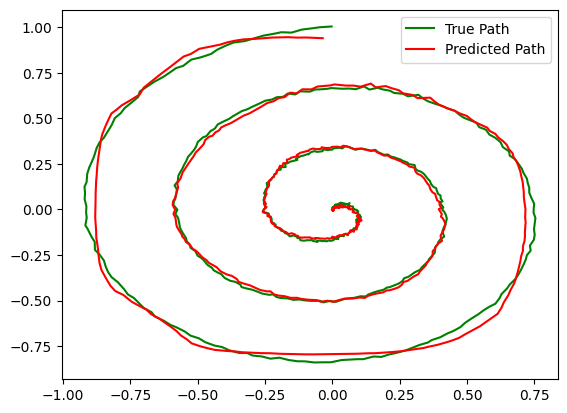

Epoch [200/2000], Total train loss: 0.0028, Total val loss: 0.0001


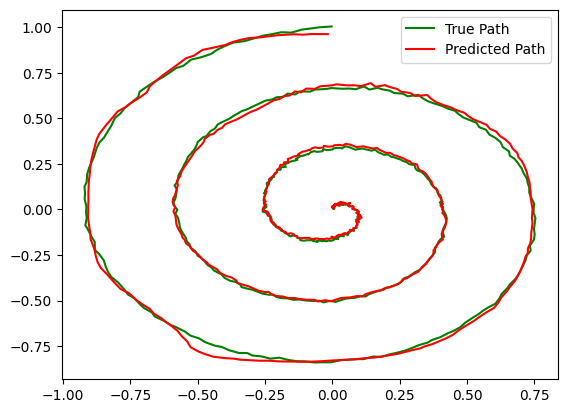

Epoch [300/2000], Total train loss: 0.0046, Total val loss: 0.0004


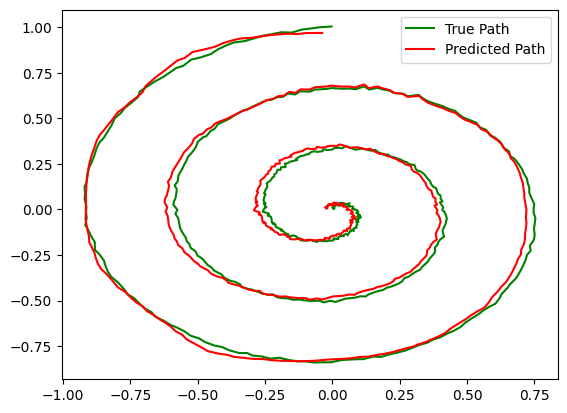

Epoch [400/2000], Total train loss: 0.0036, Total val loss: 0.0002


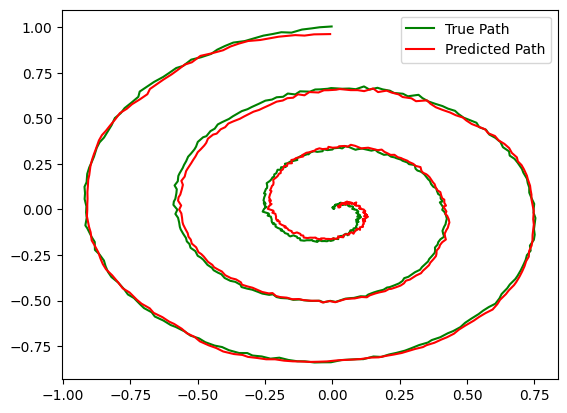

Epoch [500/2000], Total train loss: 0.0045, Total val loss: 0.0002


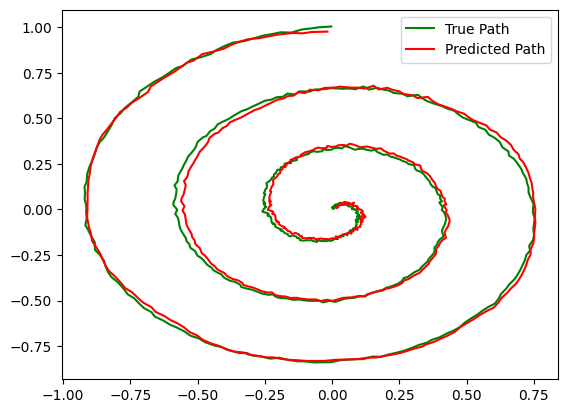

Epoch [600/2000], Total train loss: 0.0081, Total val loss: 0.0004


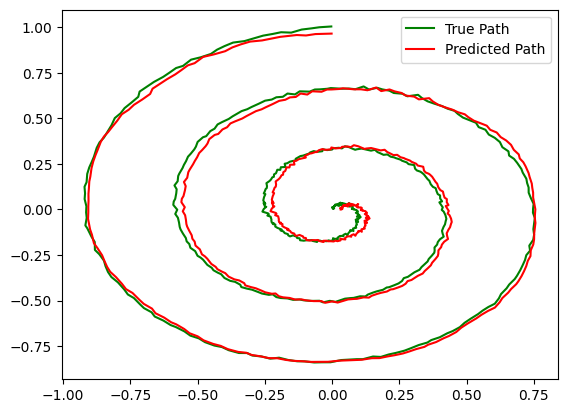

Epoch [700/2000], Total train loss: 0.0025, Total val loss: 0.0002


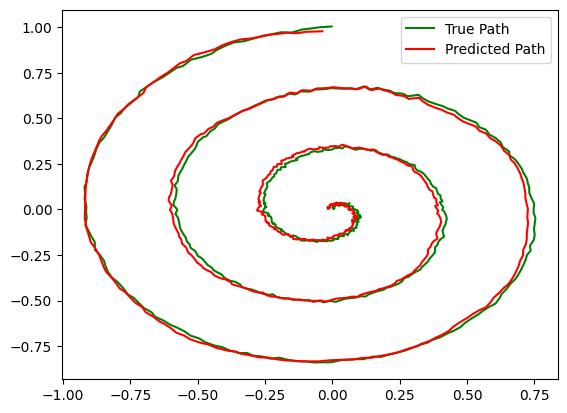

Epoch [800/2000], Total train loss: 0.0052, Total val loss: 0.0001


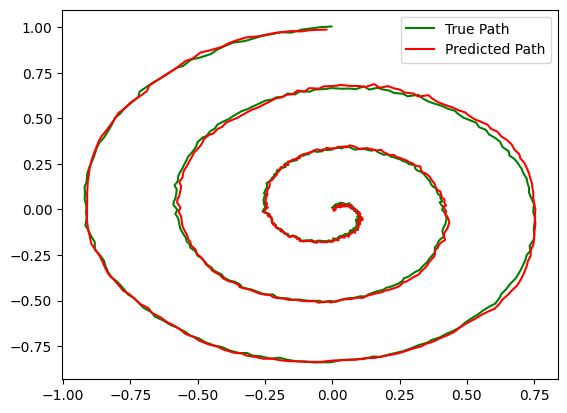

Epoch [900/2000], Total train loss: 0.0030, Total val loss: 0.0001


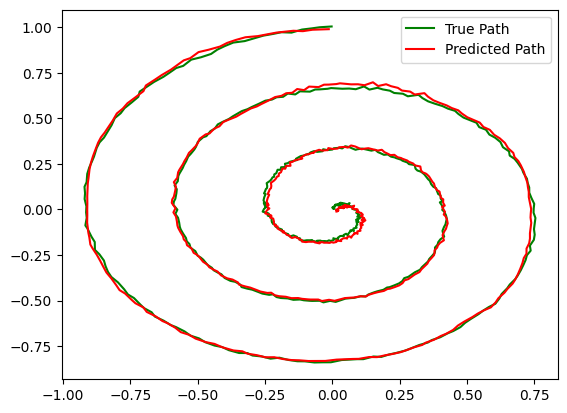

Epoch [1000/2000], Total train loss: 0.0042, Total val loss: 0.0004


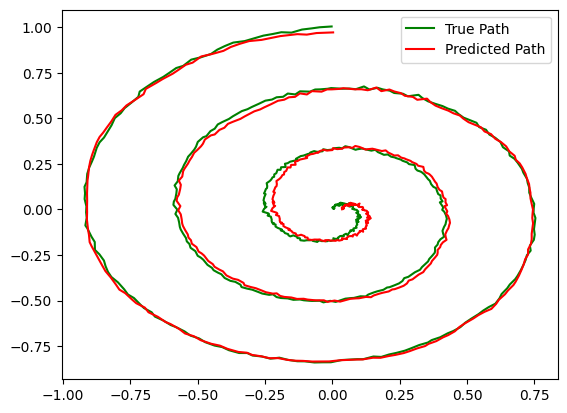

Epoch [1100/2000], Total train loss: 0.0029, Total val loss: 0.0003


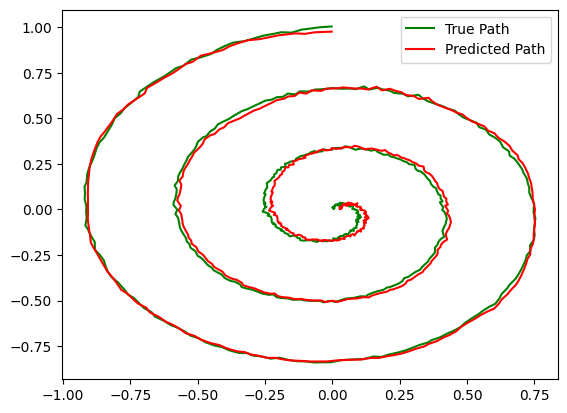

Epoch [1200/2000], Total train loss: 0.0034, Total val loss: 0.0002


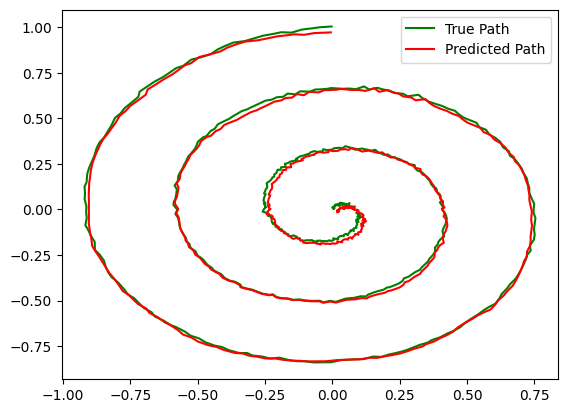

Epoch [1300/2000], Total train loss: 0.0022, Total val loss: 0.0003


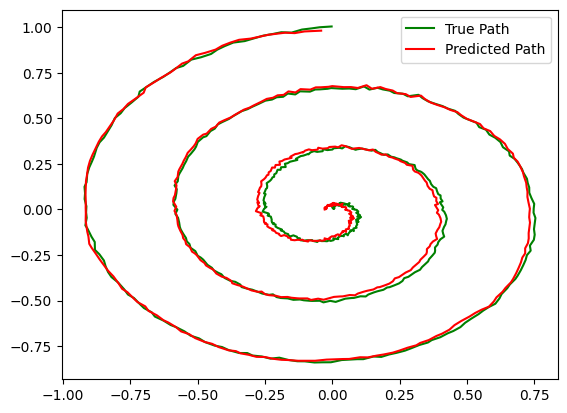

Epoch [1400/2000], Total train loss: 0.0055, Total val loss: 0.0004


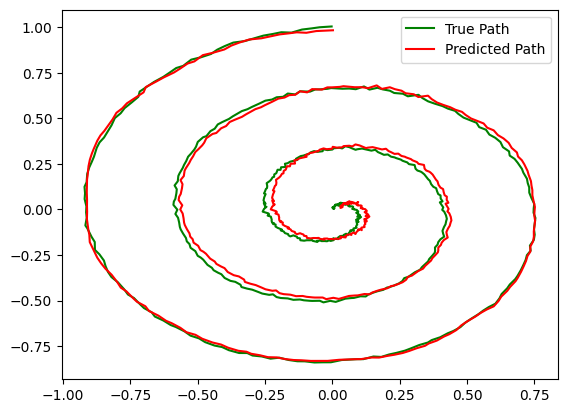

Epoch [1500/2000], Total train loss: 0.0037, Total val loss: 0.0002


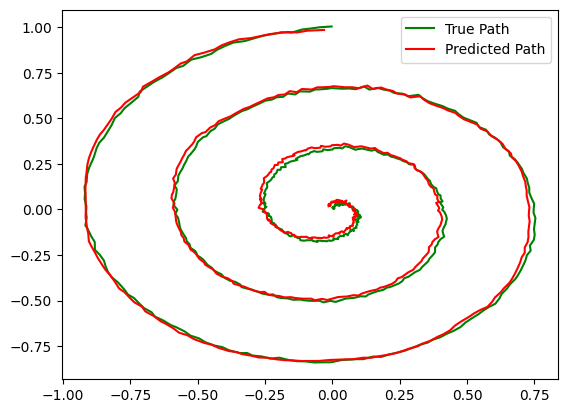

Epoch [1600/2000], Total train loss: 0.0024, Total val loss: 0.0003


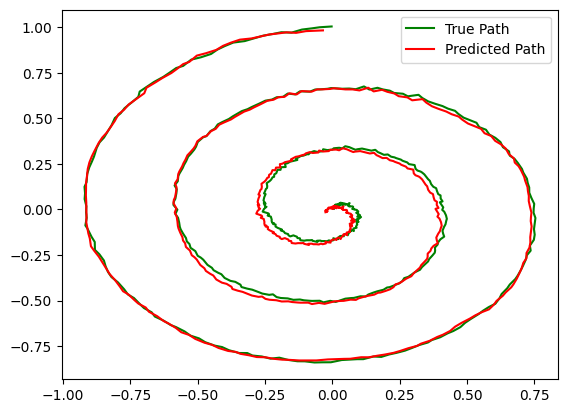

Epoch [1700/2000], Total train loss: 0.0042, Total val loss: 0.0005


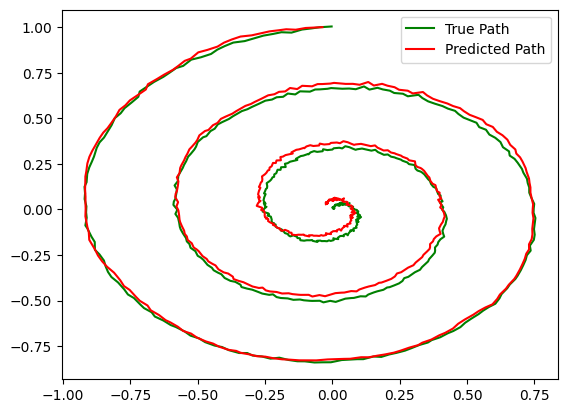

Epoch [1800/2000], Total train loss: 0.0041, Total val loss: 0.0004


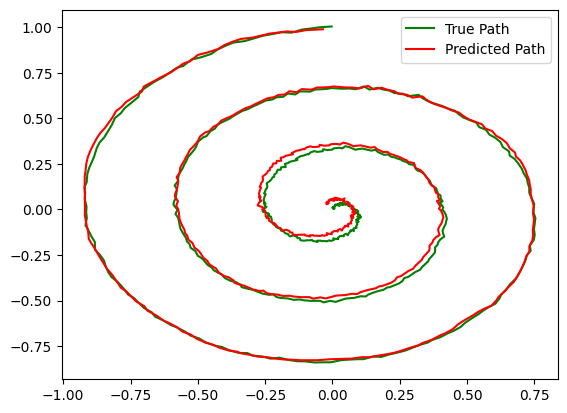

Epoch [1900/2000], Total train loss: 0.0021, Total val loss: 0.0003


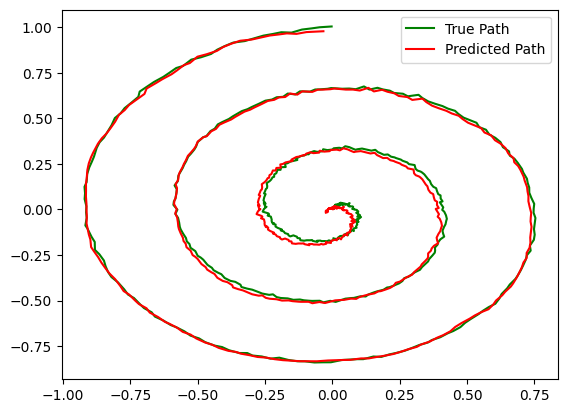

Epoch [2000/2000], Total train loss: 0.0025, Total val loss: 0.0001


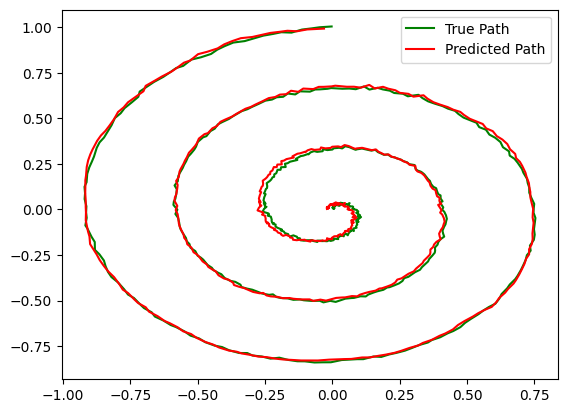

In [14]:
# 7 Train model

#hyperparams
input_dim = 2 # Number of input dimensions
hidden_dim = 8 # Number of hidden dimensions (number of neurons in LIFNeuralLayer)
output_dim = 2 # Number of output dimensions
num_points = 500 # Number of spiral points in dataset
num_turns = 3 # Number of spiral turns
learning_rate = 0.005
num_epochs = 2000
seq_len = 3 # Maximum length of the sample sequence
batch_size = 32

# generate data
data = generate_spiral_data(num_points, num_turns)
all_inputs = data[:-1, :]
all_targets = data[1:, :]

#prepare input and target sequences
trajectory_count = max(1, len(all_inputs) - seq_len)
train_inputs = [torch.FloatTensor(all_inputs[i:i+seq_len]) for i in range(trajectory_count)]
train_targets = [torch.FloatTensor(all_targets[i:i + seq_len]) for i in range(trajectory_count)]

#shuffle and split data for training
random_train_indices = np.arange(len(train_inputs))
np.random.shuffle(random_train_indices)
train_split_index = int(len(random_train_indices) * 0.8)
random_train_indices = random_train_indices[:train_split_index]

#function to create batches
def create_batches(data_list, batch_size):
    return [data_list[i:i+batch_size] for i in range(0, len(data_list), batch_size)]

#create input and target batches
train_input_batches = create_batches(train_inputs, batch_size)
train_target_batces = create_batches(train_targets, batch_size)

#initialize model
wiring = RandomWiring(input_dim, output_dim, hidden_dim)
model = LTCRNN(wiring, input_dim, hidden_dim, output_dim)

#define loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

#training loop
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    #iterate over batches
    for x, y_target in zip(train_input_batches, train_target_batces):
        optimizer.zero_grad()
        x = torch.stack(x) #stack batch of sequences
        y_target = torch.stack(y_target) #stack batch of targets
        outputs = model(x) #forward pass through model
        loss = criterion(outputs, y_target) #compute loss

        #accumulate total loss and perform backward pass and optimization step
        total_loss +=loss.item()
        loss.backward()
        optimizer.step()

    #print loss every 100 epochs and plot predictions
    if (epoch + 1) % 100 == 0:
        model.eval()
        with torch.no_grad():
            predictions = model(torch.FloatTensor(all_inputs).unsqueeze(0))
            np_predictions = predictions.squeeze(0).numpy()
            val_loss = criterion(predictions, torch.FloatTensor(all_targets).unsqueeze(0))
        print(f'Epoch [{epoch+1}/{num_epochs}], Total train loss: {total_loss:.4f}, Total val loss: {val_loss:.4f}')

        plt.plot(all_targets[:, 0], all_targets[:, 1], 'g-', label='True Path')
        plt.plot(np_predictions[:, 0], np_predictions[:, 1], 'r-', label='Predicted Path')
        plt.legend()
        plt.show()
